# When Linear Regression Lies (Part 1)
When starting with Machine learning, everyone starts with linear regression, and I did too. While I understood how to fit a model and interpret its output, I wanted to understand **why** it works and, more importantly, **when** it stops working.

In this notebook, we'll generate our own dataset from scratch. Then, one by one, we'll intentionally violate each assumption behind linear regression and observe what changes. By the end, we should have a much better intuition for what these assumptions mean and why they matter (Hopefully).


## Building the Dataset

We'll first generate our feature **X** using `np.random.uniform()`, which samples values uniformly between **0** and **10**. Next, we'll generate the error term using `noise = np.random.normal(0, 2, n)`. Finally, we'll generate the target using `Y = 7 + 3X + noise`, *where **7** is the intercept and **3** is the slope (where the line starts and how steep it is)*. We will then fit a Linear Regression model that will be treated as the baseline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 1337
X = np.random.uniform(0, 10, n)

In [2]:
from sklearn.linear_model import LinearRegression

def fit_regression(X, Y):
    df = pd.DataFrame({"X": X, "Y": Y})

    model = LinearRegression()
    model.fit(df[["X"]], df["Y"])

    df["prediction"] = model.predict(df[["X"]])
    df["residual"] = df["Y"] - df["prediction"]

    return df, model

In [3]:
noise = np.random.normal(0, 2, n)
Y = 5 + 3 * X + noise

df, model = fit_regression(X, Y)

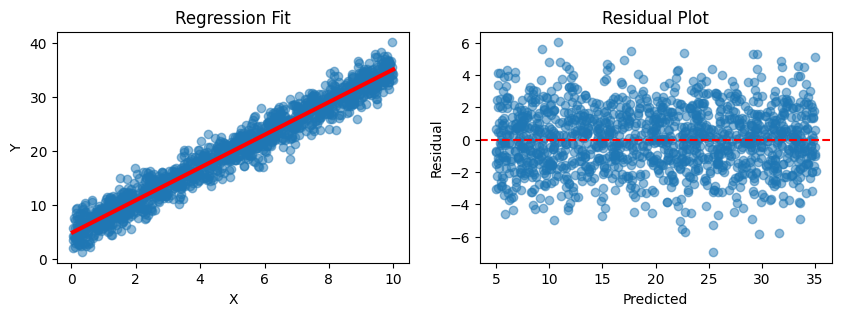

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

order = np.argsort(df["X"])

ax1.scatter(df["X"], df["Y"], alpha=0.5)
ax1.plot(df["X"].values[order], df["prediction"].values[order], "r", lw=3)
ax1.set(xlabel="X", ylabel="Y", title="Regression Fit")

ax2.scatter(df["prediction"], df["residual"], alpha=0.5)
ax2.axhline(0, color="red", ls="--")
ax2.set(xlabel="Predicted", ylabel="Residual", title="Residual Plot")

plt.show()

## Breaking Assumption 1 - Linearity

**Assumption 1:** The relationship between the predictor (X) and the target (Y) is linear. In its simplest form,
  $$ y = ax + b + \text{noise} $$
  or, more generally,
  $$ y_i = \theta^T x_i + \epsilon_i $$

Now breaking linearity is easy. Let's add a non-linear term (I am using x²) while generating the data (Y). 

In [5]:
Y = 7 + 3*X + X**2 + noise
df_1, model_1 = fit_regression(X, Y)

## Breaking Assumption 2 - Normality
**Assumption 2:** The errors (residuals) are normally distributed. Now what this simply means is that if we take all the noise an plot it, we will get a [bell curve](https://en.wikipedia.org/wiki/The_Bell_Curve). In the baseline model we use the normal function to generate "normal errors" `noise = np.random.normal(0,2,n)`.

To break normality we just need to change how we generate the noise. I am using an exponential function.

In [6]:
noise = np.random.exponential(2, n)
noise -= noise.mean()
Y = 7 + 3*X + noise
df_2, model_2 = fit_regression(X, Y)

## Breaking Assumption 3 - Homoscedasticity
**Assumption 3:** The errors should have roughly the same spread across all values of the predictor (x) (*Don't worry, nobody can pronounce homoscedasticity.*)

In the baseline data, since every error is sampled from the same distribution, each observation has the same variance
noise = np.random.normal(0, `variance = 2`, n)

To break homoscedasticity, we need to have difference variance for each Y. I am using X/2 as variance to generate the noise.

In [7]:
noise = np.random.normal(0, X/2, n)
Y = 7 + 3*X + noise
df_3, model_3 = fit_regression(X, Y)

## Breaking Assumption 4 - Independance of Errors

**Assumption 4:** One error should not influence another. 

To break assumption 4, we need to generate the next noise using the previous noise.

In [8]:
noise = np.zeros(n)
for i in range(1, n):
    noise[i] = 0.8 * noise[i-1] + np.random.normal(0,2)
Y = 7 + 3*X + noise
df_4, model_4 = fit_regression(X, Y)

## Breaking Assumption 5 - Influential Outlier

**Assumption 5:** No single observation should have a disproportionate effect on the fitted model. In the baseline model we did not intentionally introduce any influential outliers. Because X is sampled uniformly between 0 and 10, and the errors come from a normal distribution, we expect very few extreme observations and none that should disproportionately influence the fitted model. To break this assumption, we need to add one extreme datapoint.

In [9]:
Y = 7 + 3*X + noise
df_5, model_5 = fit_regression(X, Y)
df_5.loc[len(df_5)] = [20, 150, 0, 0]

model_5 = LinearRegression()
model_5.fit(df_5[["X"]], df_5["Y"])

df_5["prediction"] = model_5.predict(df_5[["X"]])
df_5["residual"] = df_5["Y"] - df_5["prediction"]

## Understanding what changes?

For understanding what violating each assumption does, we will take two approaches, Visual and Statistical. For visual we will get plot of the origianl data and the fitted model for each scenario, plot of residuals, histogram of residuals and qq plot. For statistical analysis we will look towards Slope, Intercept, R², RMSE, Shapiro p, Breusch-Pagan p, Durbin-Watson, Max VIF

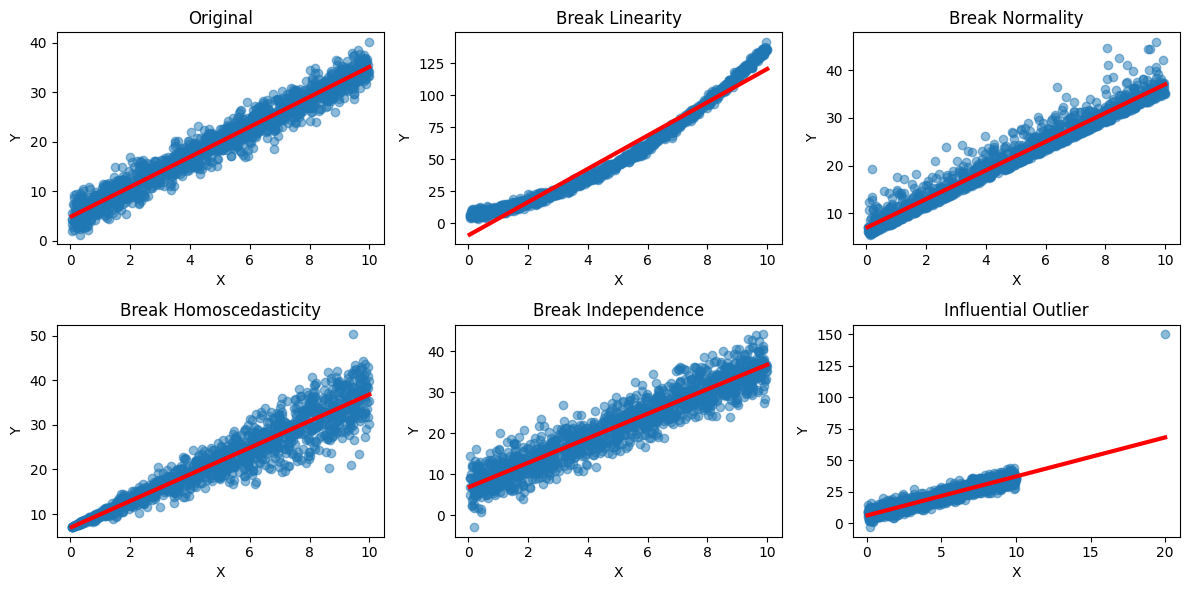

In [10]:
datasets = {"Original": df, "Break Linearity": df_1, "Break Normality": df_2, "Break Homoscedasticity": df_3, 
            "Break Independence": df_4, "Influential Outlier": df_5,}

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for ax, (title, data) in zip(axes.ravel(), datasets.items()):
    order = np.argsort(data["X"])
    ax.scatter(data["X"], data["Y"], alpha=0.5)
    ax.plot(data["X"].values[order], data["prediction"].values[order], color="red", linewidth=3)
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

plt.tight_layout()
plt.show()

The original data with the fitted regression line is surprisingly limited as a diagnostic tool. Except for obvious non-linearity or extreme outliers, most regression assumption violations are difficult to detect visually from this plot alone. This is we will move on to the next diagnostic tool: residuals

## Residual Plot
This plot shows the residuals (actual errors that we get {model - actual data}) against the model's predicted values. Since residuals represent the part of the data that the model could not explain, any systematic pattern in this plot suggests that the model has missed something important. Ideally, the residuals should appear as a random cloud centered around the zero line with no visible shape or structure. If you have a specific structure = something went wrong.

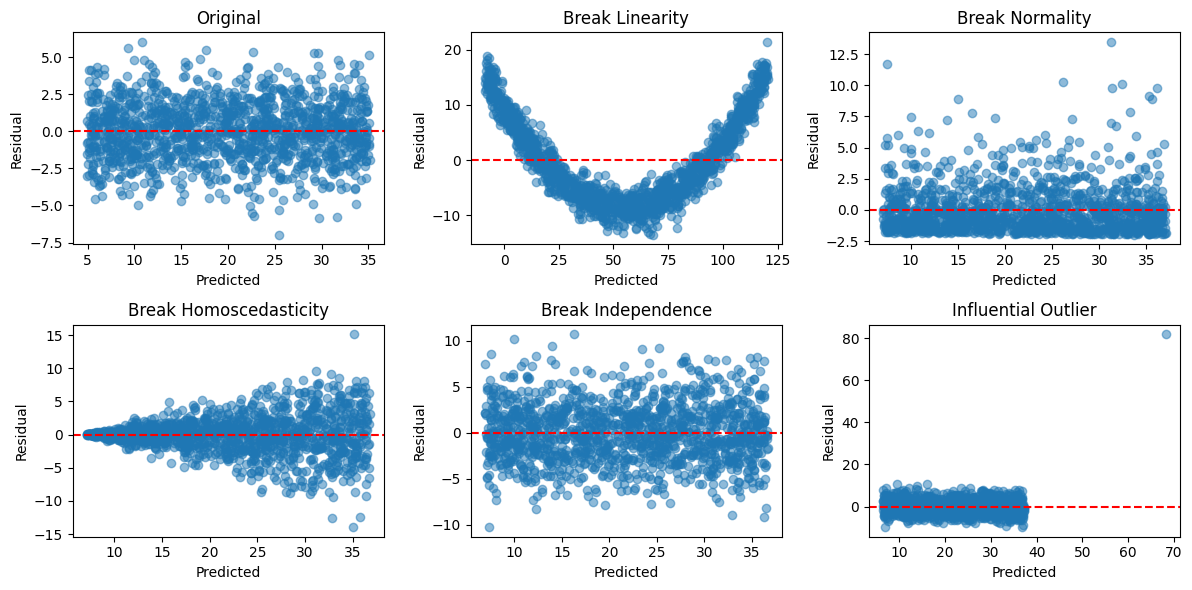

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for ax, (title, data) in zip(axes.ravel(), datasets.items()):
    ax.scatter(data["prediction"], data["residual"], alpha=0.5)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual")

plt.tight_layout()
plt.show()

While you might not get these exact plots (will vary based on the degree of violation and dataset), the patterns highlights **common diagnostic signature**. For example, non-linearity often produces curved patterns, and heteroscedasticity often produces a funnel shape, but the exact shape can vary.

## Residual Histogram Plot

Ideally the histogram should resemble a symmetric bell-shaped curve centered around zero (Normal Distribution).

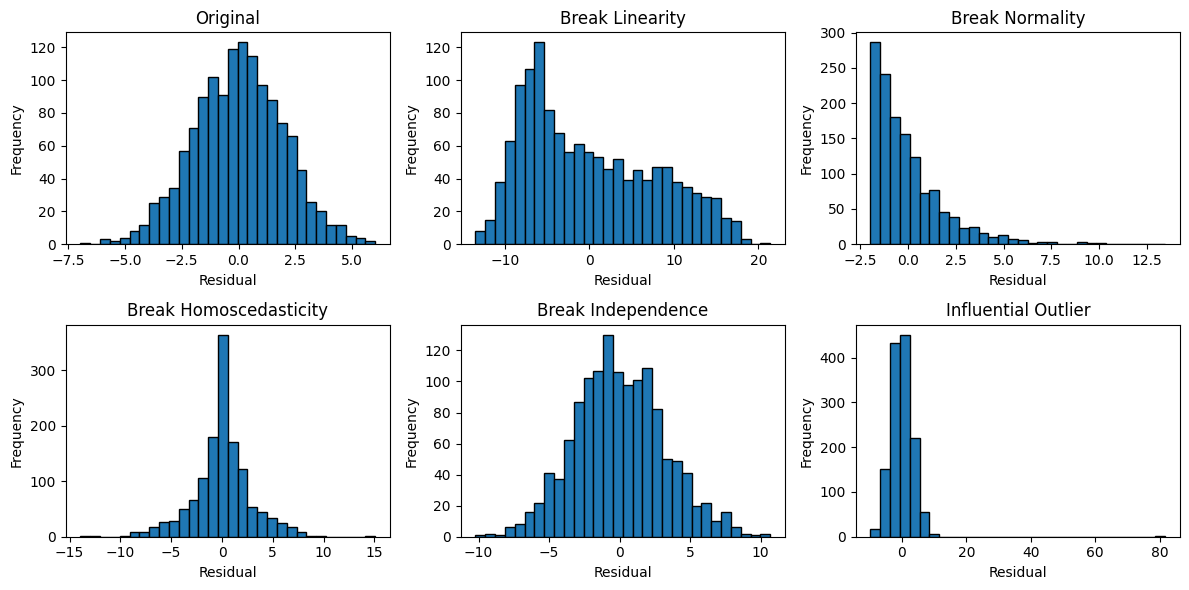

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for ax, (title, data) in zip(axes.ravel(), datasets.items()):
    ax.hist(data["residual"], bins=30, edgecolor="black")
    ax.set_title(title)
    ax.set_xlabel("Residual")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

This visualization focuses on the distribution of errors and ignores where those errors occur. Unlike the residual plot, the histogram is primarily useful for assessing normality. It provides very little information about linearity, homoscedasticity, or independence. A residual plot is excellent for detecting patterns in the errors, while a histogram is useful for examining their distribution. It is better to combine the diagnostics.

## Q-Q Plot

A **Quantile-Quantile plot** compares your residuals with what they would look like if they came from a perfect normal distribution.

Suppose you have **5 residuals**. First sort them from smallest to largest. Then generate **5 theoretical values** that a perfectly normal distribution would have. *(Don't worry the q-q plot will do it for you)*
| Perfect Normal | Actual Residual |
|----------------:|----------------:|
| -1.28 | -1.30 |
| -0.52 | -0.45 |
| 0.00 | 0.10 |
| 0.52 | 0.60 |
| 1.28 | 1.20 |

Each row becomes a point on the graph. Points plotted are: (-1.28, -1.30), (-0.52, -0.45), (0.00, 0.10), (0.52, 0.60), (1.28, 1.20)

The red 45° reference line represents the ideal case: (-1.28, -1.28) ..... (1.28, 1.28)

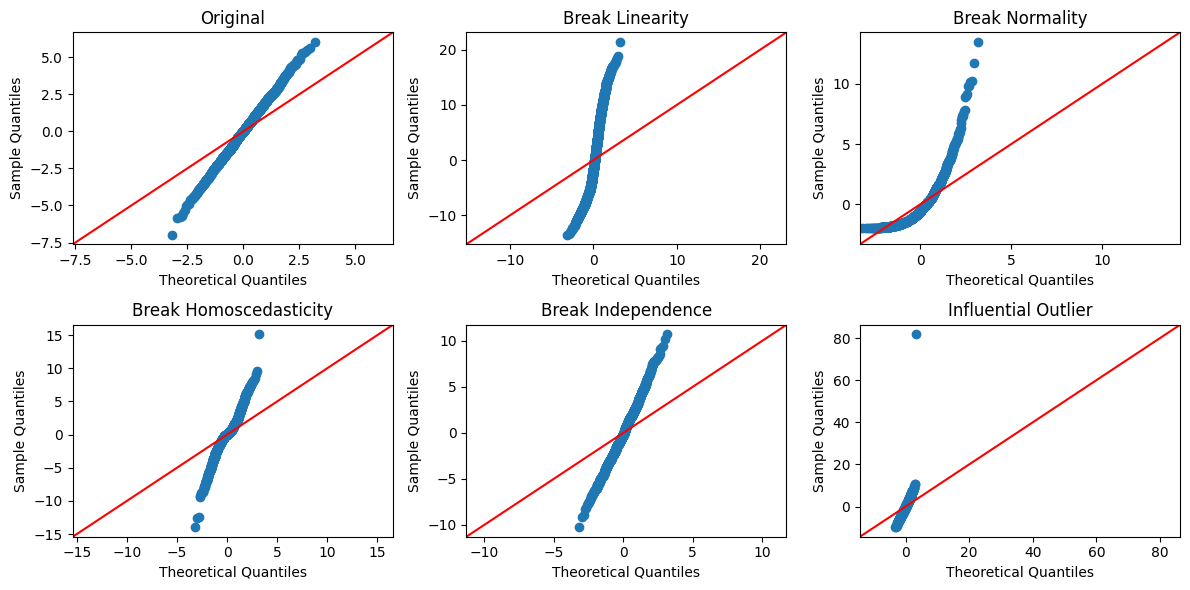

In [13]:
from statsmodels.graphics.gofplots import qqplot

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (title, data) in zip(axes.ravel(), datasets.items()):
    qqplot(data["residual"], line="45", ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Cook's Distance

Cook's Distance measures how much **each observation influences the fitted regression model**. To calculate it, the model is fitted repeatedly, each time leaving out one observation. If removing an observation causes the regression line to change significantly, that observation receives a high Cook's Distance.

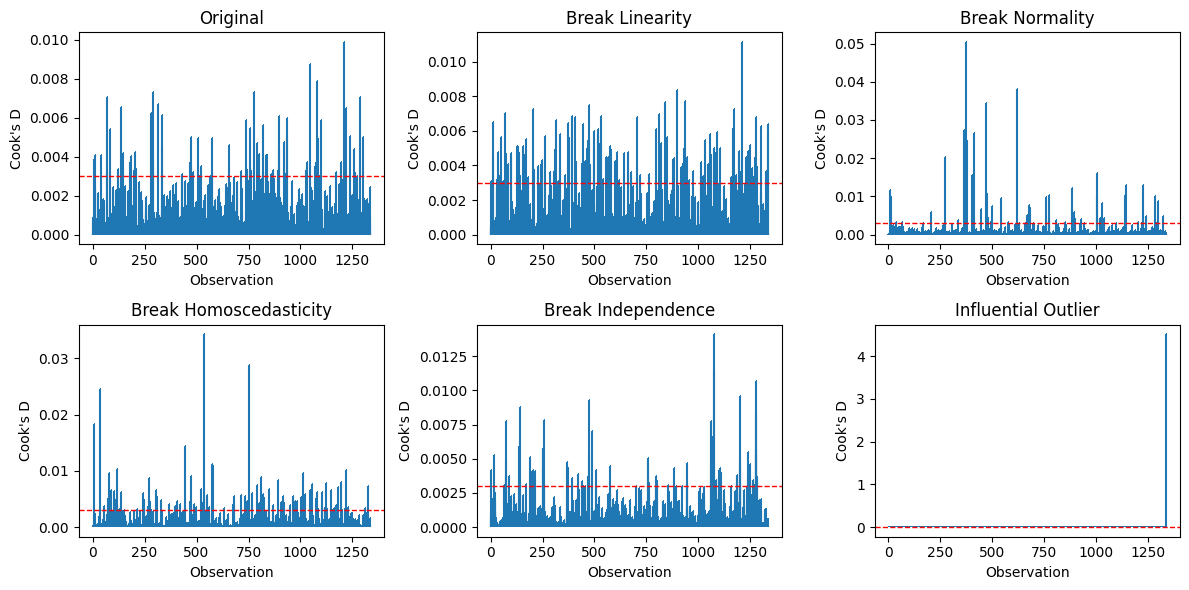

In [14]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for ax, (title, data) in zip(axes.ravel(), datasets.items()):

    X_sm = sm.add_constant(data["X"])
    model_ols = sm.OLS(data["Y"], X_sm).fit()
    influence = OLSInfluence(model_ols)
    cooks = influence.cooks_distance[0]

    ax.stem(range(len(cooks)), cooks, markerfmt=",", basefmt=" ")
    ax.axhline(4/len(data), color="red", linestyle="--", linewidth=1, label="4/n")
    ax.set_title(title)
    ax.set_xlabel("Observation")
    ax.set_ylabel("Cook's D")

plt.tight_layout()
plt.show()

* Cook's Distance is best to identify **influential observations**.
* A large Cook's Distance does **not** necessarily mean the observation is incorrect, it simply means the fitted model depends heavily on that observation.
* Most assumption violations (linearity, normality, homoscedasticity, and independence) affect many observations simultaneously and therefore do not usually produce extremely large Cook's Distance values.
* A single influential outlier, however, is immediately obvious because its Cook's Distance is dramatically larger than all other observations.

## Observations

The statistical metrics confirm many of the patterns observed in the plots we generated previously, while also revealing violations that are difficult to detect visually.

In [15]:
from scipy.stats import shapiro
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

def evaluate_model(model, df):
    X = sm.add_constant(df[["X"]])
    residuals = df["residual"]

    return {
        "Slope": model.coef_[0],
        "Intercept": model.intercept_,
        "R²": r2_score(df["Y"], df["prediction"]),
        "RMSE": np.sqrt(mean_squared_error(df["Y"], df["prediction"])),
        "Shapiro p": shapiro(residuals).pvalue,
        "Breusch-Pagan p": het_breuschpagan(residuals, X)[1],
        "Durbin-Watson": durbin_watson(residuals),
        "Max VIF": max(variance_inflation_factor(X.values, i) for i in range(1, X.shape[1]))
    }

In [16]:
results = pd.DataFrame({
    "Original": evaluate_model(model, df),
    "Break Linearity": evaluate_model(model_1, df_1),
    "Break Normality": evaluate_model(model_2, df_2),
    "Break Homoscedasticity": evaluate_model(model_3, df_3),
    "Break Independence": evaluate_model(model_4, df_4),
    "Influential Outlier": evaluate_model(model_5, df_5),
}).T

results.round(2)

,Slope,Intercept,R²,RMSE,Shapiro p,Breusch-Pagan p,Durbin-Watson,Max VIF
Original,3.03,4.79,0.95,1.97,0.98,0.88,2.06,1.0
Break Linearity,12.99,-9.30,0.96,7.74,0.00,0.15,1.91,1.0
Break Normality,3.01,6.94,0.95,1.94,0.00,0.26,1.97,1.0
Break Homoscedasticity,2.98,6.98,0.90,2.87,0.00,0.00,2.00,1.0
Break Independence,2.99,6.77,0.88,3.19,0.05,0.26,0.45,1.0
Influential Outlier,3.10,6.30,0.85,3.91,0.00,0.00,0.65,1.0



We will take "Original" as baseline. In the original data, the residuals are approximately normal (high Shapiro p-value), have constant variance (high Breusch-Pagan p-value), are independent (Durbin-Watson ≈ 2), and the model explains about 95% of the variance (R² = 0.95).
* When we **break Linearity** the slope changes dramatically from **3.03** to **12.99**, showing that the model is trying to fit a straight line to a non-linear relationship.
* **R² is still very high (0.96)** ➤ good R² does not guarantee that the model assumptions are satisfied.
* When we **break Normality** The Shapiro-Wilk p-value drops to nearly zero (residuals are no longer normally distributed). However, the slope, R², and RMSE remain unchanged, showing that non-normality affects statistical inference rather than predictive performance.
* When we **break Homoscedasticity** The Breusch-Pagan p-value becomes highly significant (non-constant variance). R² decreases, RMSE increases ➤ prediction quality also deteriorated.
* When we **break Independence** The Durbin-Watson statistic drops from **2.06** to **0.45** ➤ positive autocorrelation.
* In case of existence of **Influential Outlier** drastically reduces the model performance (R² falls to **0.85**, RMSE increases to **3.91**). 

### Key Takeaways
* R² and RMSE measure model fit, not whether the regression assumptions are satisfied.
*A model can have an excellent R² while still violating important assumptions.*
* Each statistical test is designed to detect a specific problem:
  * **Shapiro-Wilk:** Normality of residuals.
  * **Breusch-Pagan:** Constant variance (homoscedasticity).
  * **Durbin-Watson:** Independence of residuals.
  * **VIF:** Multicollinearity among predictors.